<a href="https://colab.research.google.com/github/vamsiram89/-Projects/blob/main/Amazon_web_scraping_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup Environment in Google Colab

In [19]:
!pip install requests beautifulsoup4 pandas


Import Required Libraries

In [20]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random


In [21]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np

#extracting each product details


In [22]:
# Function to extract Product Title
def get_title(soup):

    try:
        # Outer Tag Object
        title = soup.find("span", attrs={"id":'productTitle'})

        # Inner NavigatableString Object
        title_value = title.text

        # Title as a string value
        title_string = title_value.strip()

    except AttributeError:
        title_string = ""

    return title_string

# Function to extract Product Price
def get_price(soup):

    try:
        price = soup.find("span", attrs={'class':'a-price'}).string.strip()

    except AttributeError:

        try:
            # If there is some deal price
            price = soup.find("span", attrs={'class':'a-offscreen'}).string.strip()

        except:
            price = ""

    return price

# Function to extract Product Rating
def get_rating(soup):

    try:
        rating = soup.find("i", attrs={'class':'a-icon a-icon-star a-star-4-5'}).string.strip()

    except AttributeError:
        try:
            rating = soup.find("span", attrs={'class':'a-icon-alt'}).string.strip()
        except:
            rating = ""

    return rating

# Function to extract Number of User Reviews
def get_review_count(soup):
    try:
        review_count = soup.find("span", attrs={'id':'acrCustomerReviewText'}).string.strip()

    except AttributeError:
        review_count = ""

    return review_count

# Function to extract Availability Status
def get_availability(soup):
    try:
        available = soup.find("div", attrs={'id':'availability'})
        available = available.find("span").string.strip()

    except AttributeError:
        available = "Not Available"

    return available

In [23]:
if __name__ == '__main__':

    # add your user agent
    HEADERS = ({'User-Agent':'', 'Accept-Language': 'en-US, en;q=0.5'})

    # The webpage URL
    URL = "https://www.amazon.com/s?k=playstation+4&ref=nb_sb_noss_2"

    # HTTP Request
    webpage = requests.get(URL, headers=HEADERS)

    # Soup Object containing all data
    soup = BeautifulSoup(webpage.content, "html.parser")

    # Fetch links as List of Tag Objects
    links = soup.find_all("a", attrs={'class':'a-link-normal s-no-outline'})

    # Store the links
    links_list = []

    # Loop for extracting links from Tag Objects
    for link in links:
            links_list.append(link.get('href'))

    d = {"title":[], "price":[], "rating":[], "reviews":[],"availability":[]}

    # Loop for extracting product details from each link
    for link in links_list:
        new_webpage = requests.get("https://www.amazon.com" + link, headers=HEADERS)

        new_soup = BeautifulSoup(new_webpage.content, "html.parser")

        # Function calls to display all necessary product information
        d['title'].append(get_title(new_soup))
        d['price'].append(get_price(new_soup))
        d['rating'].append(get_rating(new_soup))
        d['reviews'].append(get_review_count(new_soup))
        d['availability'].append(get_availability(new_soup))


    amazon_df = pd.DataFrame.from_dict(d)
    amazon_df['title'].replace('', np.nan, inplace=True)
    amazon_df = amazon_df.dropna(subset=['title'])
    amazon_df.to_csv("amazon_data.csv", header=True, index=False)

/tmp/ipython-input-418/3016206517.py:42: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [24]:
amazon_df

,title,price,rating,reviews,availability
2,Sony PlayStation 4 Slim Limited Edition 1TB Ga...,,Previous set of slides,,Not Available
3,Sony PlayStation 4 Dual Player Gaming Bundle (...,,Previous set of slides,,Not Available
5,PlayStation®5 Digital Edition (slim),,Previous set of slides,,Not Available
7,Zeust PlayStation 4 Slim 1TB Console Bundle - ...,$274.99,3.9 out of 5 stars,(71),Only 17 left in stock - order soon.
9,"Playstation SONY 4, 500GB Slim System [CUH-221...",$189.99,4.3 out of 5 stars,(658),Only 9 left in stock - order soon.
11,Sony PlayStation 4 Console 1TB - Black (Renewed),$209.98,3.8 out of 5 stars,(88),In Stock
13,PlayStation 4,,Previous set of slides,,Not Available


In [25]:
import matplotlib.pyplot as plt

## Visualization 1: Bar Chart for Ratings

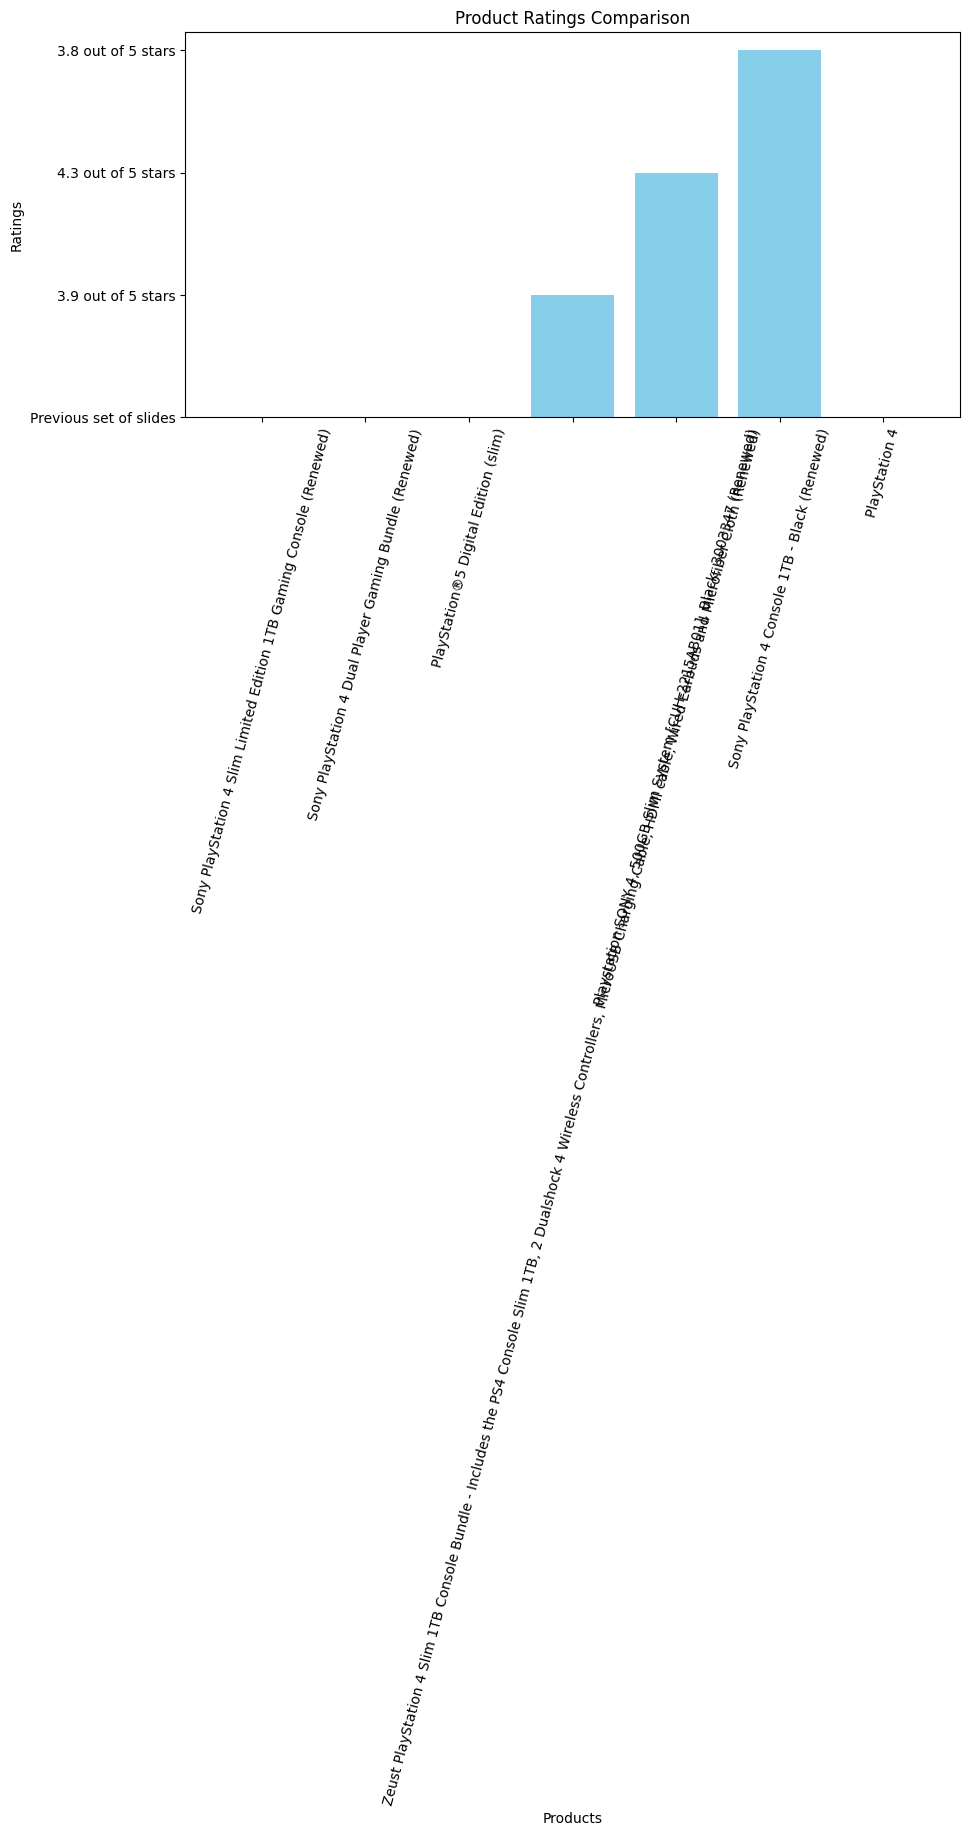

In [26]:
# 🔹 Visualization 1: Bar Chart for Ratings
plt.figure(figsize=(10, 5))
plt.bar(amazon_df["title"],amazon_df["rating"], color="skyblue")
plt.xlabel("Products")
plt.ylabel("Ratings")
plt.title("Product Ratings Comparison")
plt.xticks(rotation=75)
plt.show()

In [27]:
import plotly.express as px

fig2 = px.pie(amazon_df,
              names="availability",
              title="Product Availability",
              color="availability",
              hover_data=["title"],  # 👈 This adds product names on hover
              color_discrete_map={"In Stock": "green",
                                  "Not Available": "red",
                                  "Only 5 left in stock - order soon.": "orange",
                                  "Only 15 left in stock - order soon.": "blue"})

fig2.update_traces(hoverinfo="label+percent+text", textinfo="percent", text=amazon_df["title"])  # 👈 Customizing hover

fig2.show()
